In [5]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(SingleCellExperiment)
    library(Seurat)
    library(data.table)
    library(dplyr)
    library(gridExtra)
    library(viridis)
    library(reticulate)
    library(edgeR)
    library(ggrastr)
    library(ggrepel)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

In [9]:
# Running UMAP from python
source_python(paste0('/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/UMAP_R_to_py.py'))
run_umap = function(pca_in){
    umap = as.data.frame(umap_redu(pca_in))
    colnames(umap) = c('umap_1', 'umap_2')
    rownames(umap) = meta$cell
    return(umap)    
}

umap_theme =  theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1))

In [7]:
main = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Erythroid/'

meta = read.csv(paste0(main, 'erythroid_atlas_meta.csv'))
uncorrected = read.csv(paste0(main, 'uncorrected_PCs.csv'))
corrected = read.csv(paste0(main, 'corrected_PCs.csv'))


In [41]:
umap_corr = run_umap(uncorrected[,2:16])

In [45]:
head(umap_corr)

,umap_1,umap_2
,<dbl>,<dbl>
cao_1000018,-1.990798,2.8026516
cao_1000043,-1.738098,3.0462048
cao_1000066,-2.156837,2.8582249
cao_1000107,10.029841,2.8433986
cao_1000145,9.966198,4.3090196
cao_1000147,10.121668,-0.1579295


In [47]:
meta = merge(meta, umap_corr, by.x='cell',by.y=0)

In [48]:
head(meta)

,cell,sample,stage,celltype,exp,umap_1,umap_2
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,cao_1000018,cao_11.5,E11.5,Definitive erythroid lineage,cao,-1.990798,2.8026516
2,cao_1000043,cao_12.5,E12.5,Intermediate Mesoderm,cao,-1.738098,3.0462048
3,cao_1000066,cao_13.5,E13.5,White blood cells,cao,-2.156837,2.8582249
4,cao_1000107,cao_12.5,E12.5,Intermediate Mesoderm,cao,10.029841,2.8433986
5,cao_1000145,cao_10.5,E10.5,Primitive erythroid lineage,cao,9.966198,4.3090196
6,cao_1000147,cao_11.5,E11.5,Primitive erythroid lineage,cao,10.121668,-0.1579295


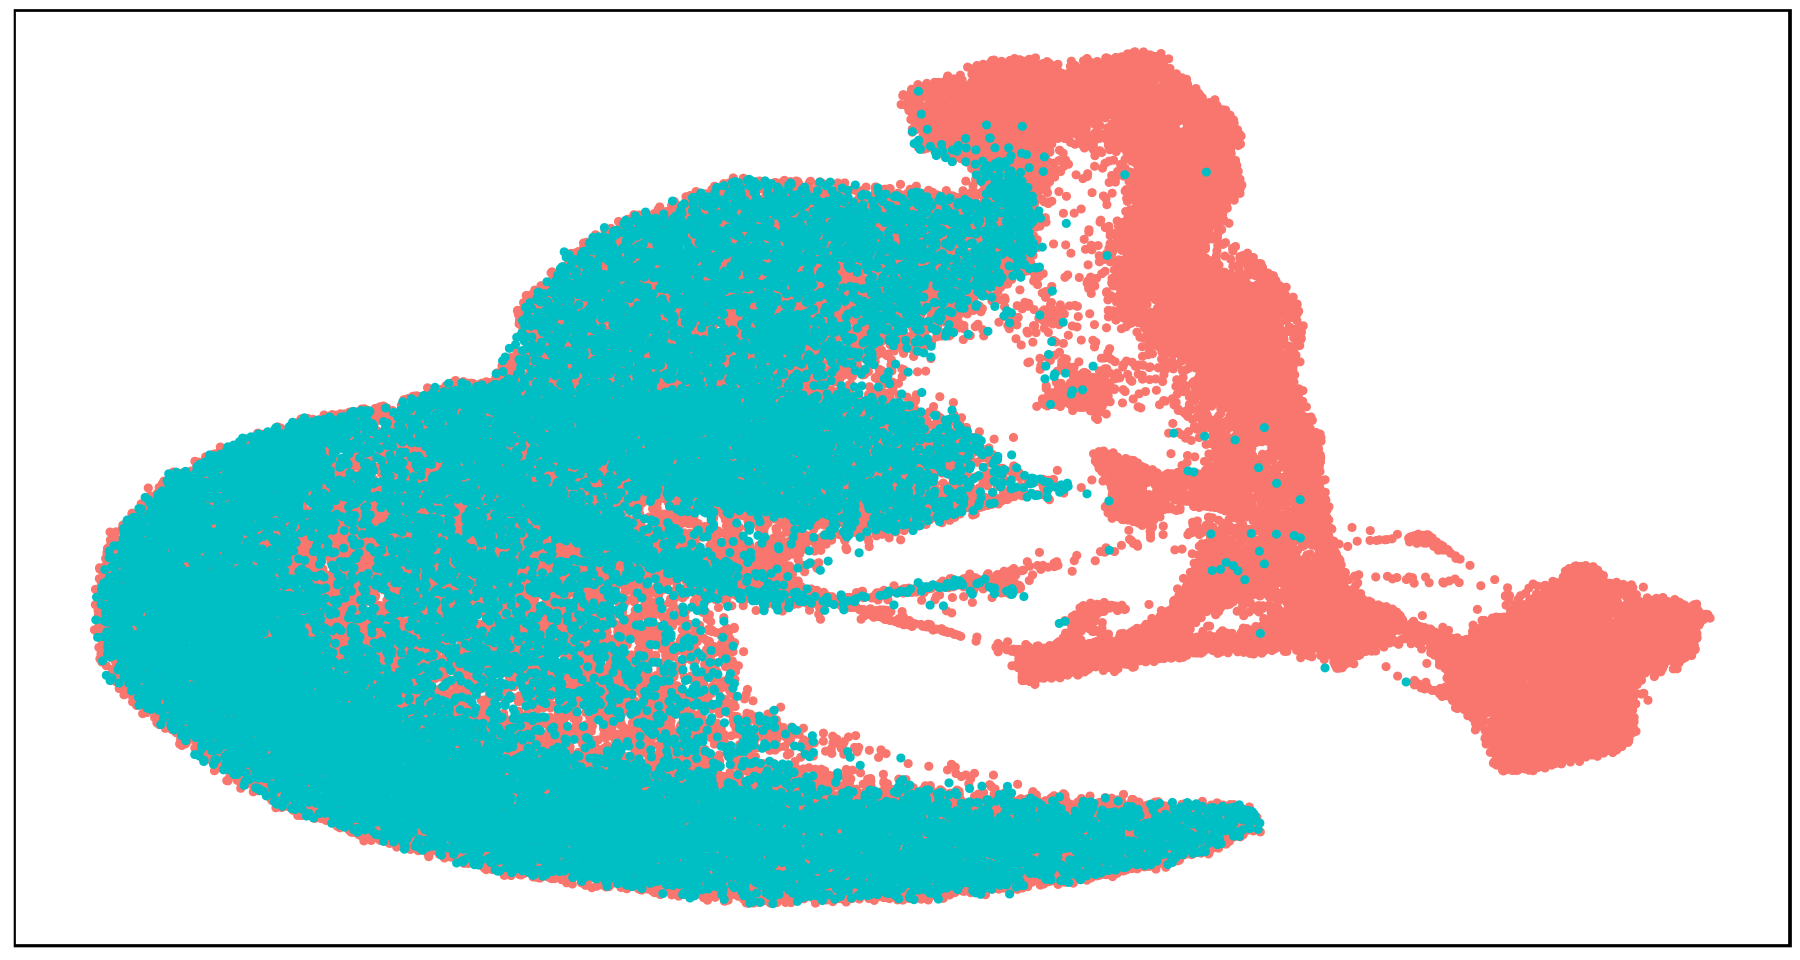

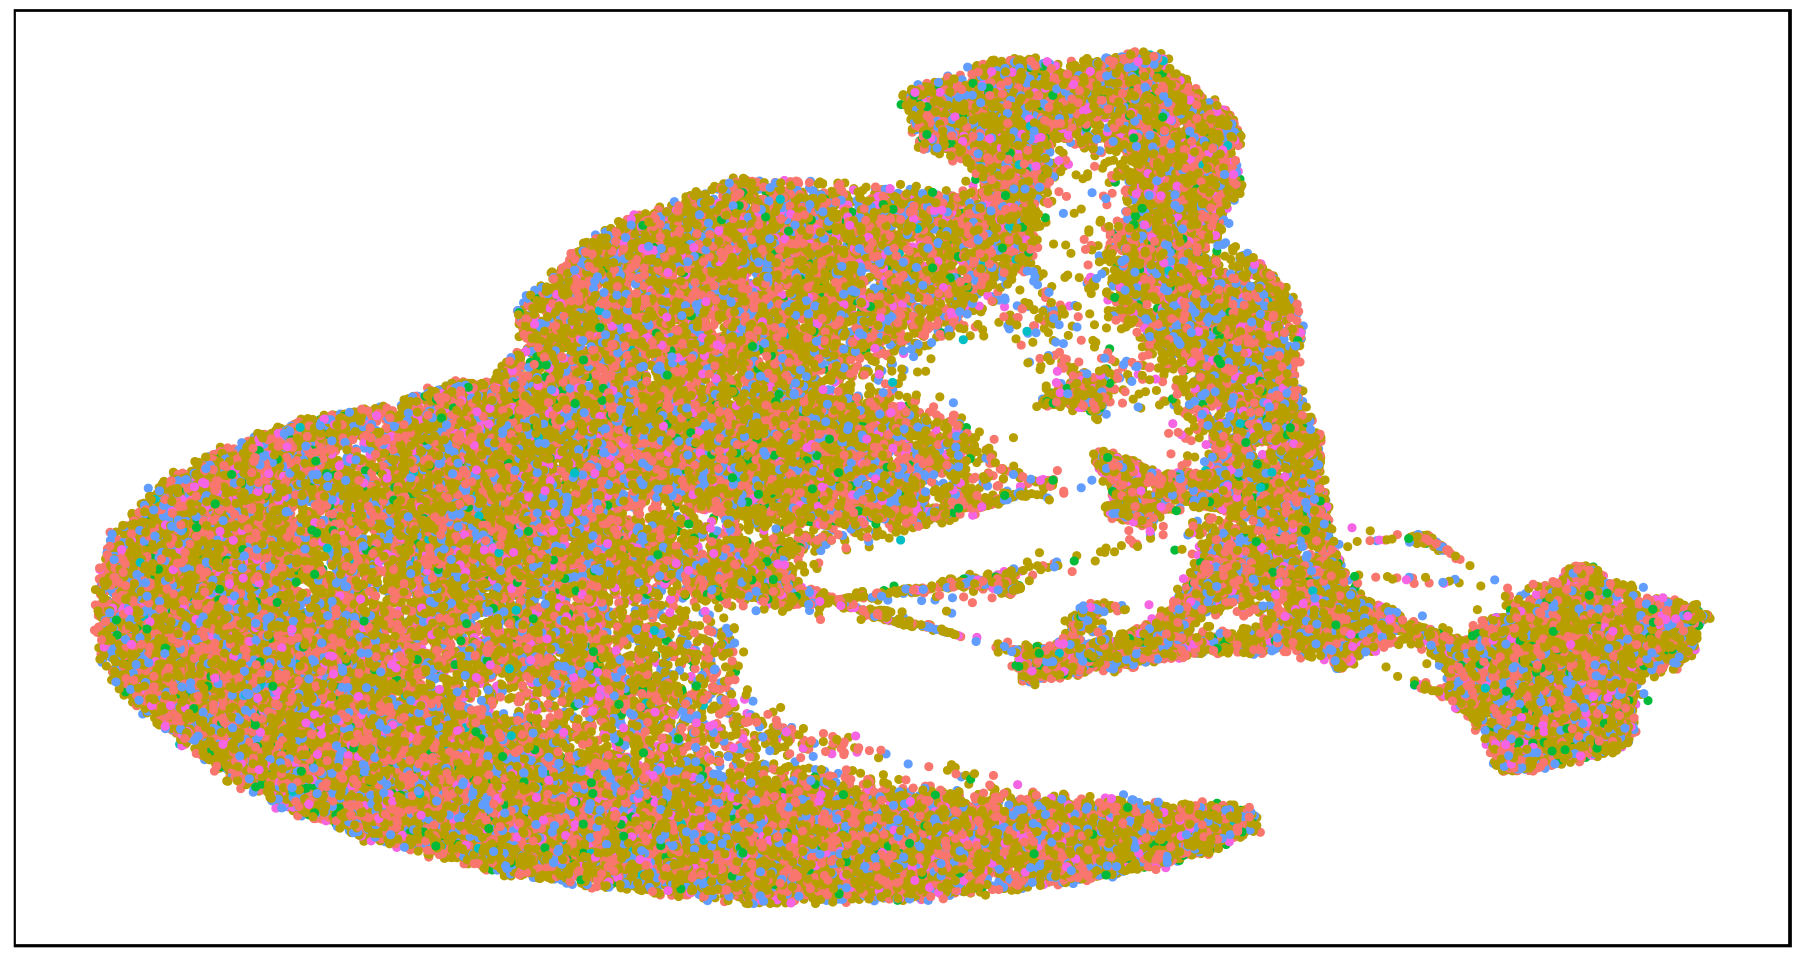

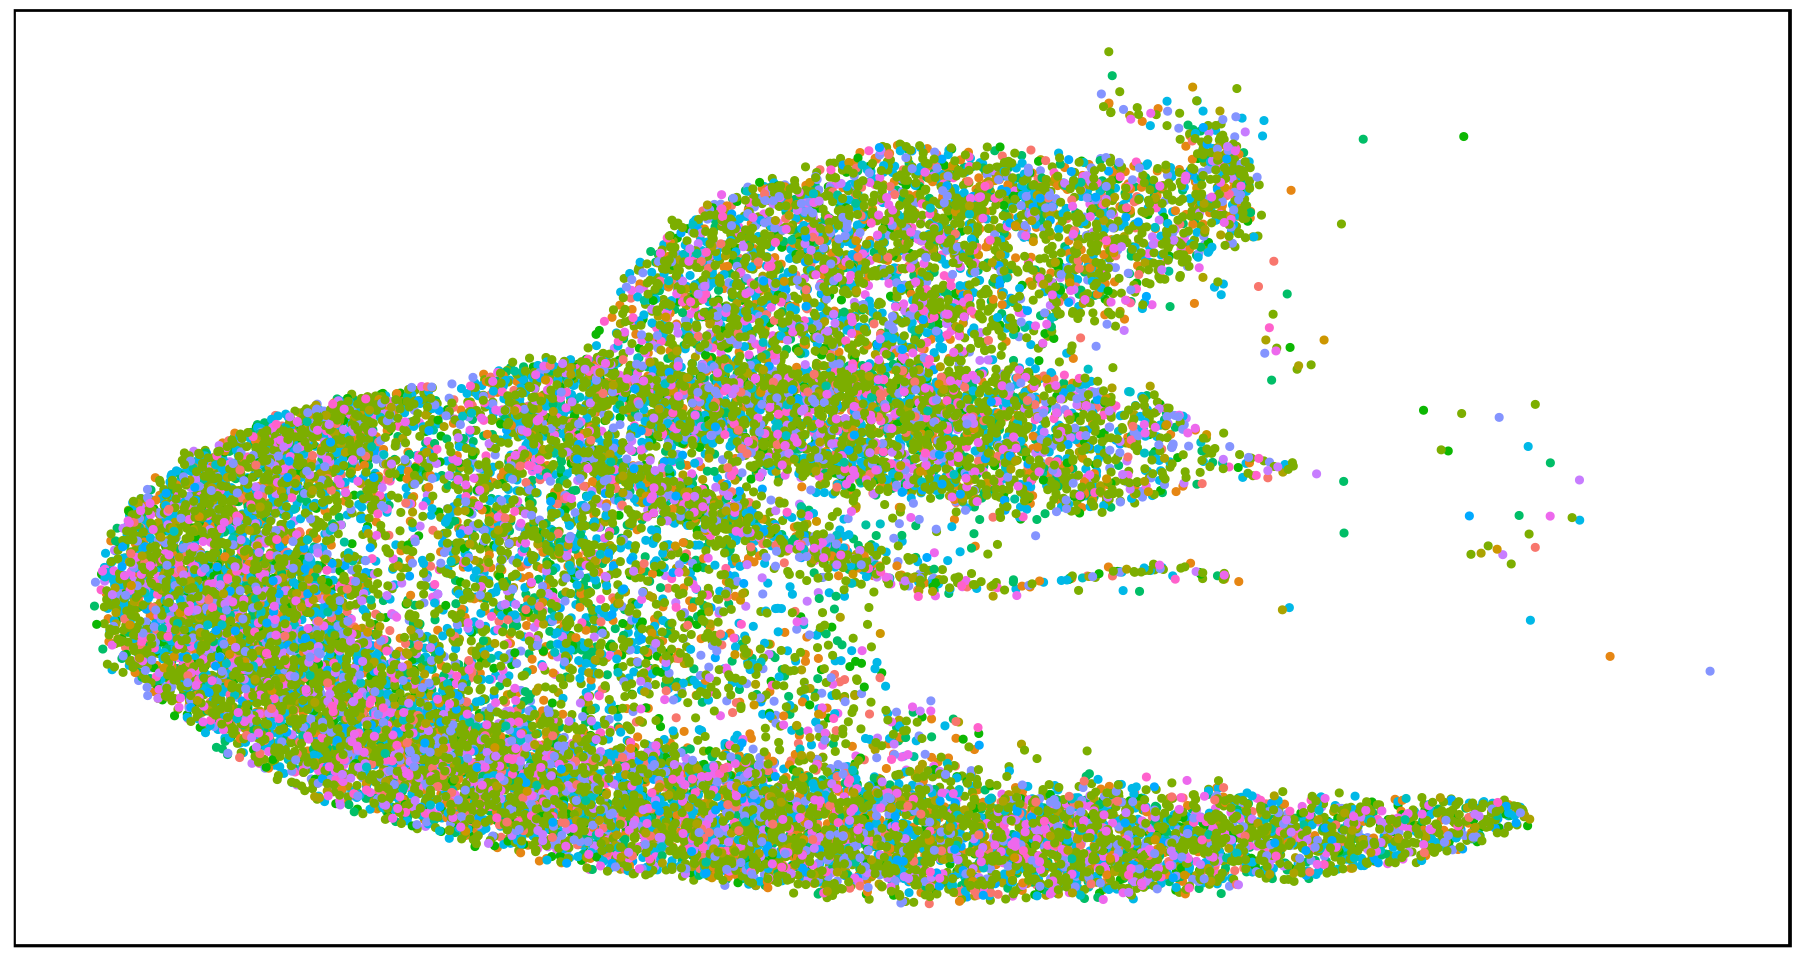

In [49]:
ggplot(meta, aes(umap_1,umap_2, col=exp)) + 
    geom_point() + 
    umap_theme

ggplot(meta[meta$exp=='cao',], aes(umap_1,umap_2, col=celltype)) + 
    geom_point() + 
    umap_theme

ggplot(meta[meta$exp!='cao',], aes(umap_1,umap_2, col=celltype)) + 
    geom_point() + 
    umap_theme

In [52]:
unique(meta$celltype)

[1] "Definitive erythroid lineage"                  
 [2] "Intermediate Mesoderm"                         
 [3] "White blood cells"                             
 [4] "Primitive erythroid lineage"                   
 [5] "Neutrophils"                                   
 [6] "Megakaryocytes"                                
 [7] "NMPs/Mesoderm-biased"                          
 [8] "Erythroid"                                     
 [9] "Allantois endothelium"                         
[10] "Nascent mesoderm"                              
[11] "Presomitic mesoderm"                           
[12] "Blood progenitors"                             
[13] "Haematoendothelial progenitors"                
[14] "Somitic mesoderm"                              
[15] "Venous endothelium"                            
[16] "Embryo proper endothelium"                     
[17] "MEP"                                           
[18] "Intermediate mesoderm"                         
[19] "YS endothelium"                                
[20] "Chorioallantoic-derived erythroid progenitors" 
[21] "Megakaryocyte progenitors"                     
[22] "YS mesothelium-derived endothelial progenitors"

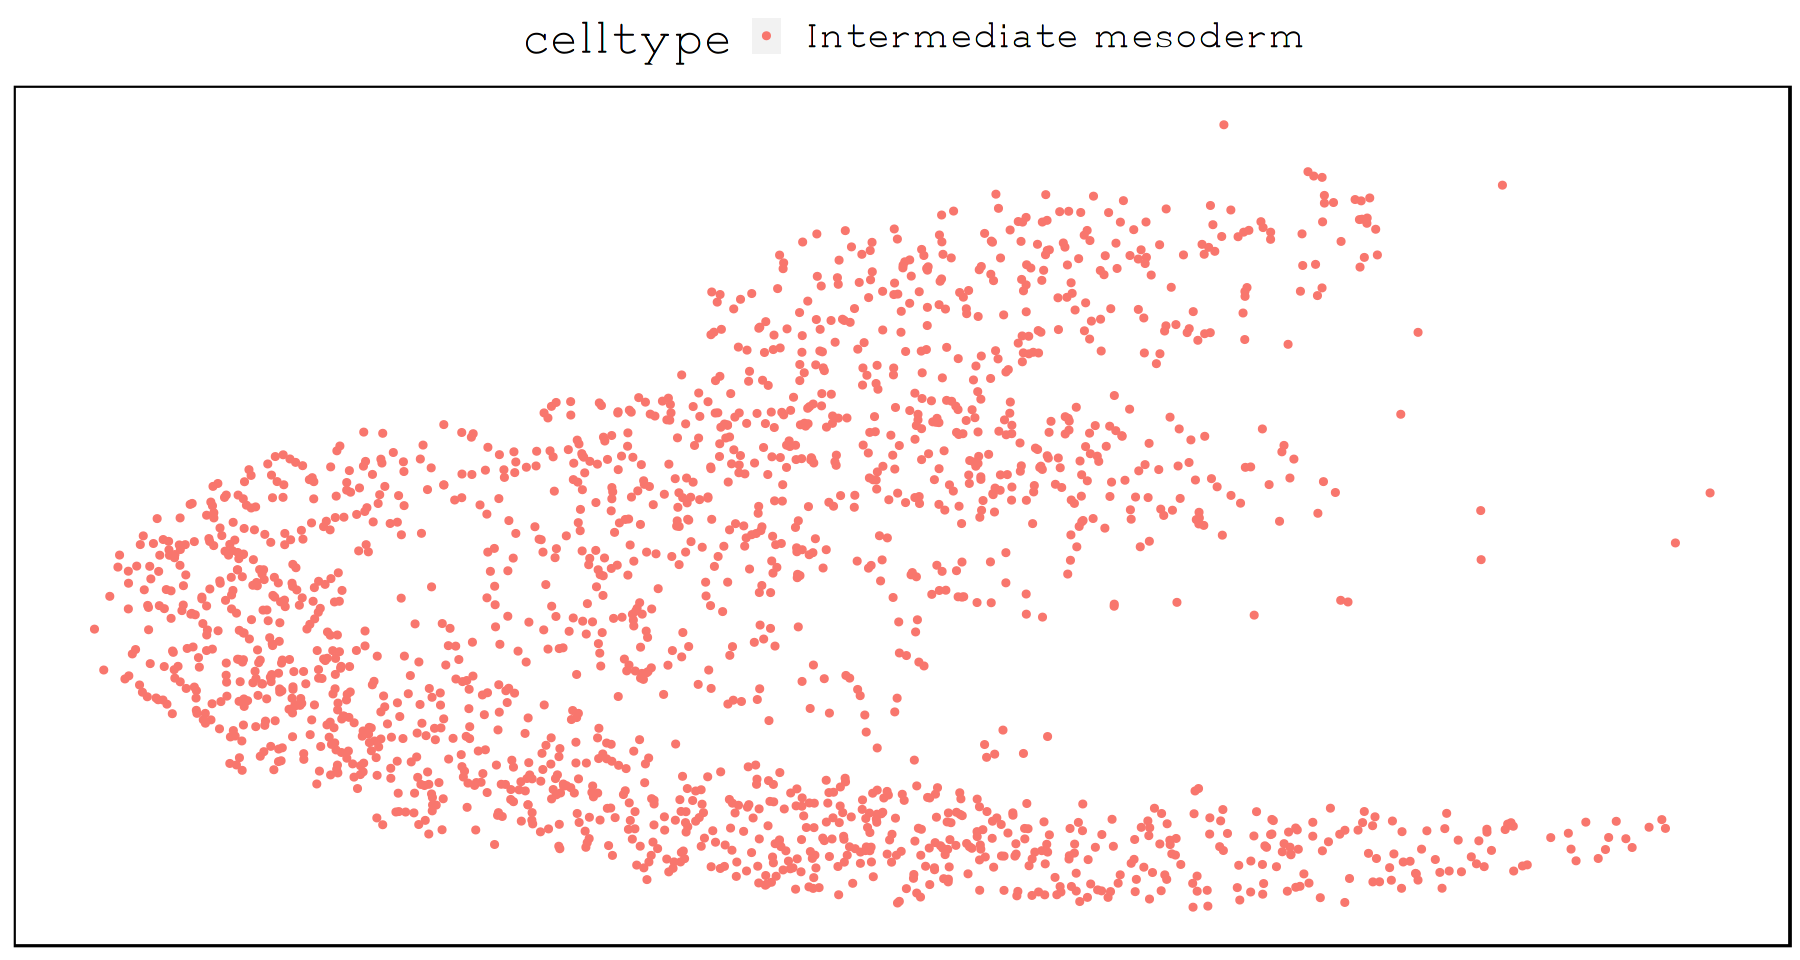

In [58]:
ggplot(meta[meta$celltype=='Intermediate mesoderm',], aes(umap_1,umap_2, col=celltype)) + 
    geom_point() + 
    umap_theme + theme(legend.position='top')